In [2]:
from dataclasses import dataclass, field
from typing import Callable, Optional, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np

In [40]:
LblL, LblM, LblR = 0, 1, 2   # tri-state labels

@dataclass
class IntervalResult:
    x1: Optional[float]
    x2: Optional[float]
    n_iter: Optional[int]
    history: Dict[str, np.ndarray]  # x, f1, f2, label per eval, plus per-iter notes

@dataclass
class JointIntervalFinder:
    f: Callable[[float, float], float]  # expensive black box
    y1: float
    y2: float
    r1: float
    r2: float
    x_start: float               # your “reasonably near x1” guess
    w_start: float = 1.0         # initial window half-width
    Nmax: int = 20               # batch size ceiling for final pass
    tol_frac: float = 0.1        # stop when bracket widths <= tol_frac * window
    max_iters: int = 50
    x2_mode: str = "min_ge"
    rng: np.random.Generator = field(default_factory=lambda: np.random.default_rng(0))

    # internal state
    X: List[float] = field(default_factory=list)
    F1: List[float] = field(default_factory=list)
    F2: List[float] = field(default_factory=list)
    lbl: List[int] = field(default_factory=list)
    notes: List[Dict] = field(default_factory=list)

    _allL_run: int = 0
    _allR_run: int = 0

    def _pass2(self, f1: float, f2: float) -> bool:   # NEW
        m = self.x2_mode
        if   m == "min_ge": return min(f1, f2) >= self.r2
        elif m == "min_le": return min(f1, f2) <= self.r2
        elif m == "y1_ge":  return f1 >= self.r2
        elif m == "y1_le":  return f1 <= self.r2
        elif m == "y2_ge":  return f2 >= self.r2
        elif m == "y2_le":  return f2 <= self.r2
        else:
            raise ValueError(f"Unknown x2_mode: {m}")

    def _label(self, f1, f2):
        mx = max(f1, f2)
        if mx < self.r1: return LblL
        if self._pass2(f1, f2): return LblR
        return LblM

    def _eval_points(self, xs: np.ndarray):
        for x in xs:
            f1 = self.f(x, self.y1)
            f2 = self.f(x, self.y2)
            self.X.append(x); self.F1.append(f1); self.F2.append(f2)
            self.lbl.append(self._label(f1, f2))

    def _current_arrays(self):
        X = np.array(self.X); F1 = np.array(self.F1); F2 = np.array(self.F2); L = np.array(self.lbl)
        order = np.argsort(X)
        return X[order], F1[order], F2[order], L[order]

    def _brackets(self, X, L):
        """
        Return (x1_lo, x1_hi, have_x1), (x2_lo, x2_hi, have_x2), x1_hat
        x1 bracket: max L below r1 (LblL) and min not-L (LblM/R)
        x2 bracket: max not-R left of first R, min R (LblR) with x >= x1_hat
        """
        # x1
        isL = (L == LblL)
        notL = ~isL
        have_x1 = isL.any() and notL.any()
        x1_lo = X[isL].max() if isL.any() else None
        x1_hi = X[notL].min() if notL.any() else None
        x1_hat = x1_hi  # first non-L is our best "first crossing" estimate

        # x2 (only meaningful to the right of x1_hat)
        have_x2 = False; x2_lo = None; x2_hi = None
        if x1_hat is not None:
            mask_r = X >= x1_hat
            Xr, Lr = X[mask_r], L[mask_r]
            isR = (Lr == LblR)
            notR = ~isR
            if isR.any():
                have_x2 = True
                x2_hi = Xr[isR].min()
                x2_lo = Xr[notR & (Xr <= x2_hi)].max() if (notR & (Xr <= x2_hi)).any() else x1_hat
        return (x1_lo, x1_hi, have_x1), (x2_lo, x2_hi, have_x2), x1_hat

    def _choose_batch(self, A, B, N, x1_br, x2_br):
        """
        2 exploitation points at mid-brackets; (N-2) exploration via a simple adaptive mixture.
        Also caps sampling inside deep-R to avoid slow evals.
        """
        x1_lo, x1_hi, have_x1 = x1_br
        x2_lo, x2_hi, have_x2 = x2_br

        xs = []

        # exploitation
        if have_x1 and (x1_lo is not None) and (x1_hi is not None):
            xs.append(0.5 * (x1_lo + x1_hi))
        else:
            xs.append((A + B) / 2)

        if have_x2 and (x2_lo is not None) and (x2_hi is not None):
            xs.append(0.5 * (x2_lo + x2_hi))
        else:
            # if x2 unknown, aim just to the right of x1_hi if we have it, else middle
            anchor = (x1_hi + min(B, x1_hi + 0.25*(B-A))) if (have_x1 and x1_hi is not None) else (A+B)/2
            xs.append(anchor)

        # exploration support segments
        # cap far-right to avoid deep R: limit at x2_hi + cushion (if available)
        right_cap = B
        if have_x2 and (x2_hi is not None) and (x2_br[0] is not None):
            cushion = max(1e-12, (x2_hi - x2_lo))
            right_cap = min(B, x2_hi + 2*cushion)

        segs: List[Tuple[float, float, float]] = []  # (a,b,weight)

        # left neighborhood of x1 bracket
        if have_x1 and (x1_lo is not None):
            a = max(A, x1_lo - (x1_hi - x1_lo if (x1_hi and x1_lo) else 0.25*(B-A)))
            b = min(B, x1_hi if x1_hi is not None else A + 0.25*(B-A))
            if a < b:
                segs.append((a, b, (x1_hi - x1_lo) if (x1_hi and x1_lo) else 0.1*(B-A)))

        # middle
        mid_a = x1_hi if (have_x1 and (x1_hi is not None)) else A
        mid_b = (x2_hi if (have_x2 and (x2_hi is not None)) else right_cap)
        if mid_a < mid_b:
            segs.append((mid_a, mid_b, (mid_b - mid_a)))

        # right neighborhood of x2 bracket (if we have it)
        if have_x2 and (x2_lo is not None) and (x2_hi is not None):
            a = max(A, x2_lo)
            b = min(right_cap, x2_hi + (x2_hi - x2_lo))
            if a < b:
                segs.append((a, b, (x2_hi - x2_lo)))

        # fallback: whole window if nothing else
        if not segs:
            segs.append((A, right_cap, right_cap - A))

        weights = np.array([w for _, _, w in segs], float)
        if weights.sum() <= 0: weights[:] = 1.0
        weights /= weights.sum()

        # sample N-2 exploration points
        M = max(0, N - 2)
        # stratify: proportional draw per segment, low-discrepancy within each
        alloc = np.random.multinomial(M, weights)
        for (a, b, _), k in zip(segs, alloc):
            if k <= 0: continue
            # low-discrepancy: jittered linspace
            base = (np.arange(k) + 0.5) / k
            pts = a + base * (b - a)
            # small random jitter (bounded)
            jitter = self.rng.uniform(-1/6, 1/6, size=k) * (b - a) / max(k, 1)
            xs.extend((pts + jitter).tolist())

        xs = np.array(xs, float)
        xs = xs[(xs >= A) & (xs <= right_cap)]
        return xs

    def _window_update(self, X, L, A, B):
        """Adapt [A,B] from labels; expand/shift just-enough; trim deep-R or deep-L."""

        w = (B - A)
        L_mask = (L == LblL)
        R_mask = (L == LblR)

        if L_mask.all():
            self._allL_run += 1
            self._allR_run = 0
            step = w * (2 ** max(0, self._allL_run - 1))  # expand if still all-L
            return B, B + step

        if R_mask.all():
            self._allR_run += 1
            self._allL_run = 0
            step = w * (2 ** max(0, self._allR_run - 1))  # expand if still all-R
            return A - step, A

        # mixed → reset runs and keep the original mixed-case logic
        self._allL_run = self._allR_run = 0

        # Mixed:
        # Keep only the minimal range that still contains both the first non-L and the first R
        idx = np.argsort(X)
        Xs, Ls = X[idx], L[idx]
        # first non-L
        i1 = np.argmax(Ls != LblL) if (~(Ls == LblL)).any() else 0
        x1_hat = Xs[i1]
        # first R to the right of x1_hat
        mask = (Xs >= x1_hat)
        i2_candidates = np.where(mask & (Ls == LblR))[0]
        if len(i2_candidates) > 0:
            x2_hat = Xs[i2_candidates[0]]
            # small symmetric padding relative to current span
            pad = 0.25 * max(1e-12, x2_hat - x1_hat)
            return x1_hat - pad, x2_hat + pad
        else:
            # No R yet: keep a right-heavy window to discover first R
            w = (B - A)
            return x1_hat - 0.25*w, x1_hat + 1.25*w

    def run(self, N: int = 10) -> IntervalResult:
        # Initialize window around x_start (works for negative/positive x)
        A, B = self.x_start - self.w_start, self.x_start + self.w_start

        # First batch (guarantee coverage)
        xs0 = np.linspace(A, B, num=max(3, min(N, 9)))  # cheap spread
        self._eval_points(xs0)

        for it in range(self.max_iters):
            X, F1, F2, L = self._current_arrays()
            (x1_lo, x1_hi, have_x1), (x2_lo, x2_hi, have_x2), x1_hat = self._brackets(X, L)

            # stopping if both brackets are "reasonably tight" w.r.t. current window
            win = max(1e-12, B - A)
            x1_w = (x1_hi - x1_lo) if (have_x1 and x1_lo is not None and x1_hi is not None) else np.inf
            x2_w = (x2_hi - x2_lo) if (have_x2 and x2_lo is not None and x2_hi is not None) else np.inf
            done_x1 = (x1_w <= self.tol_frac * win)
            done_x2 = (x2_w <= self.tol_frac * win)
            self.notes.append(dict(iter=it, A=A, B=B, have_x1=have_x1, have_x2=have_x2,
                                   x1_lo=x1_lo, x1_hi=x1_hi, x2_lo=x2_lo, x2_hi=x2_hi,
                                   win=win, x1_w=x1_w, x2_w=x2_w))

            # If both done, finalize with Nmax near each bracket
            if done_x1 and done_x2 and np.isfinite(x1_w) and np.isfinite(x2_w):
                xs_final = []
                xs_final += [0.5*(x1_lo+x1_hi)]* (self.Nmax//2)
                xs_final += [0.5*(x2_lo+x2_hi)]* (self.Nmax - len(xs_final))
                self._eval_points(np.array(xs_final))
                # recompute final estimates
                X, _, _, L = self._current_arrays()
                # first non-L
                i1 = np.argmax(L != LblL)
                x1_est = X[i1]
                # first R to right of x1_est
                i2_candidates = np.where((X >= x1_est) & (L == LblR))[0]
                x2_est = X[i2_candidates[0]] if len(i2_candidates) else None
                return IntervalResult(x1_est, x2_est, it,
                                      dict(X=np.array(self.X), F1=np.array(self.F1),
                                           F2=np.array(self.F2), lbl=np.array(self.lbl),
                                           notes=self.notes))

            # Otherwise, choose a new batch focusing on both boundaries
            xs_next = self._choose_batch(A, B, N, (x1_lo, x1_hi, have_x1), (x2_lo, x2_hi, have_x2))
            self._eval_points(xs_next)

            # Adapt window for next round
            X, _, _, L = self._current_arrays()
            A, B = self._window_update(X, L, A, B)

        # If we exit by max_iters, return best current estimates
        X, _, _, L = self._current_arrays()
        # x1
        i1 = np.argmax(L != LblL) if (~(L == LblL)).any() else None
        x1_est = X[i1] if i1 is not None else None
        # x2
        x2_est = None
        if x1_est is not None:
            i2_candidates = np.where((X >= x1_est) & (L == LblR))[0]
            x2_est = X[i2_candidates[0]] if len(i2_candidates) else None

        return IntervalResult(x1_est, x2_est, it,
                              dict(X=np.array(self.X), F1=np.array(self.F1),
                                   F2=np.array(self.F2), lbl=np.array(self.lbl),
                                   notes=self.notes))


-4.603191651948791 1.1270736799272436
Num. iter: 1


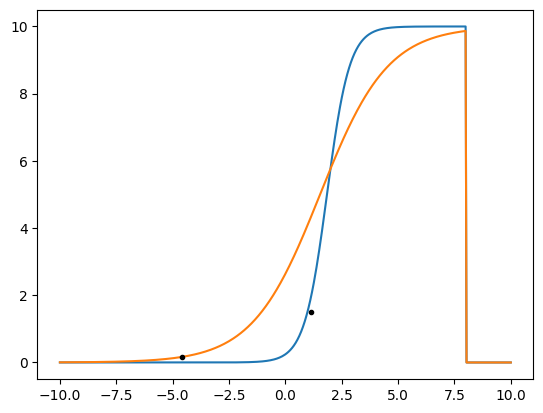

In [60]:
# Define your f(x, y) (expensive); here’s a toy bell/sigmoid hybrid for testing:
def f_demo(x, y):
    # bell centered at c(y), width s(y), height h(y), clipped to >=0
    c = 2.0 + 0.5*y
    s = 1.2 + 0.1*y
    h = 1.5 + 0.2*y
    val = h * np.exp(-0.5*((x-c-y)/s)**2)
    # add a shallow sigmoid tail to mimic monotone saturation possibility
    val += 0.4/(1.0 + np.exp(-(x - (c-2.0))))
    return val

def f_sigmoid(x, y):
    rmax = 10
    xc = 1.5
    k = 2
    r = rmax / (1 + k * np.exp(-(x - xc + y / 2) * (k / (1 + y))))
    r *= (x < 8)
    return r

r1, r2 = 0.15, 1.5
y1, y2 = 0, 2

x10, x20 = -5, 10

#f = f_demo
f = f_sigmoid

finder = JointIntervalFinder(
    f=f, y1=y1, y2=y2,
    r1=r1, r2=r2,
    x_start=x10, w_start=((x20 - x10) / 2),
    Nmax=10, tol_frac=0.1, max_iters=30,
    x2_mode='y1_ge'
)

res = finder.run(N=10)  # N<=Nmax until the last step
print(res.x1, res.x2)
print(f'Num. iter: {res.n_iter}')

plt.figure()
x = np.linspace(-10, 10, 500)
for y in [y1, y2]:
    plt.plot(x, f(x, y))
plt.plot([res.x1, res.x2], [r1, r2], 'k.')


In [9]:
from pprint import pprint
pprint(res)

IntervalResult(x1=-0.703617544902088,
               x2=1.4456377788638863,
               history={'F1': array([0.05348005, 0.0942924 , 0.17348197, 0.32225891, 0.57402831,
       0.93573378, 1.35239585, 1.70231282, 1.85231883, 0.23689387,
       1.54478629, 0.18363381, 0.39470825, 0.59840824, 0.88410185,
       1.30454936, 1.61624361, 1.55734866, 1.81951258, 0.27654869,
       1.66126367, 0.37615021, 0.52088362, 0.67295669, 0.80495839,
       1.06345343, 1.2162417 , 1.46651733, 1.61165933, 0.25599846,
       1.68230864, 0.245969  , 0.33458463, 0.46480197, 0.65576496,
       0.84816778, 1.10399614, 1.40228693, 1.62144294, 0.25093626,
       0.25093626, 0.25093626, 0.25093626, 0.25093626, 0.25093626,
       0.25093626, 0.25093626, 0.25093626, 0.25093626, 1.67191333,
       1.67191333, 1.67191333, 1.67191333, 1.67191333, 1.67191333,
       1.67191333, 1.67191333, 1.67191333, 1.67191333]),
                        'F2': array([0.03459472, 0.06263034, 0.1183072 , 0.22616532, 0.41855681,
   